# Huge Ensembles (HENS) Checkpoints

Basic multi-checkpoint Huge Ensembles (HENS) inference workflow.

This example provides a basic example to load the Huge Ensemble checkpoints to perform
ensemble inference.
This notebook aims to demonstrate the foundations of running a multi-checkpoint workflow
from Earth2Studio components.
For more details about HENS, see:

- https://arxiv.org/abs/2408.03100
- https://github.com/ankurmahesh/earth2mip-fork


!!! warning
    We encourage users to familiarize themselves with the license restrictions of this
    model's checkpoints.

For the complete HENS workflow, we encourage users to have a look at the HENS recipe
which provides a end-to-end solution to leverage HENS for downstream analysis such as
tropical cyclone tracking:

- https://github.com/NVIDIA/earth2studio/tree/main/recipes/hens

In this example you will learn:

- How to load the HENS checkpoints with a custom model package
- How to load the HENS perturbation method
- How to create a simple ensemble inference loop
- How to visualize results

## Set Up
First, import the necessary modules and set up our environment and load the required
modules.
HENS has checkpoints conveniently stored on [HuggingFace](https://huggingface.co/datasets/maheshankur10/hens/tree/main/earth2mip_prod_registry)
that we will use.
Rather than loading the default checkpoint from the original SFNO paper, create a
model package that points to the specific HENS checkpoint we want to use instead.

This example also needs the following:

- Prognostic Base Model: Use SFNO model architecture [`earth2studio.models.px.SFNO`][earth2studio.models.px.SFNO].
- Datasource: Pull data from the GFS data api [`earth2studio.data.GFS`][earth2studio.data.GFS].
- Perturbation Method: HENS uses a novel perturbation method [`earth2studio.perturbation.HemisphericCentredBredVector`][earth2studio.perturbation.HemisphericCentredBredVector].
- Seeding Perturbation Method: Perturbation method to seed the Bred Vector [`earth2studio.perturbation.CorrelatedSphericalGaussian`][earth2studio.perturbation.CorrelatedSphericalGaussian].

In [1]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # TODO: make common example prep function

from earth2studio.data import GFS
from earth2studio.io import ZarrBackend
from earth2studio.models.auto import Package
from earth2studio.models.px import SFNO
from earth2studio.perturbation import (
    CorrelatedSphericalGaussian,
    HemisphericCentredBredVector,
)
from earth2studio.run import ensemble

# Set up two model packages for each checkpoint
# Note the modification of the cache location to avoid overwriting
model_package_1 = Package(
    "hf://datasets/maheshankur10/hens/earth2mip_prod_registry/sfno_linear_74chq_sc2_layers8_edim620_wstgl2-epoch70_seed102",
    cache_options={
        "cache_storage": Package.default_cache("hens_1"),
        "same_names": True,
    },
)

model_package_2 = Package(
    "hf://datasets/maheshankur10/hens/earth2mip_prod_registry/sfno_linear_74chq_sc2_layers8_edim620_wstgl2-epoch70_seed103",
    cache_options={
        "cache_storage": Package.default_cache("hens_2"),
        "same_names": True,
    },
)

# Create the data source
data = GFS()


/localhome/local-ngeneva/.cache/uv/environments-v2/harness-d0569d6fc007940a/lib/python3.13/site-packages/torch/cuda/__init__.py:64: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## Execute the Workflow
Next we execute the ensemble workflow for each model but loop through each checkpoint.
Note that the models themselves have not been loaded into memory yet, this will be
done one at a time to minimize the memory footprint of inference on a GPU.
Before the ensemble workflow can get executed the following set up is needed:

- Initialize the SFNO model from checkpoint
- Initialize the perturbation method with the prognostic model
- Initialize the IO zarr store for this model

If multiple GPUs are being used, one could parallelize inference using different
checkpoints on each card.

In [2]:
import gc
from datetime import datetime, timedelta

import numpy as np
import torch

start_date = datetime(2024, 1, 1)
nsteps = 4
nensemble = 2

for i, package in enumerate([model_package_1, model_package_2]):
    # Load SFNO model from package
    # HENS checkpoints use different inputs than default SFNO (inclusion of d2m)
    # Can find this in the config.json, the load_model function in SFNO handles this
    model = SFNO.load_model(package)

    # Perturbation method
    # Here we will simplify the process that's in the original paper for conciseness
    noise_amplification = torch.zeros(model.input_coords()["variable"].shape[0])
    index_z500 = list(model.input_coords()["variable"]).index("z500")
    noise_amplification[index_z500] = 39.27  # z500 (0.35 * z500 skill)
    noise_amplification = noise_amplification.reshape(1, 1, 1, -1, 1, 1)

    seed_perturbation = CorrelatedSphericalGaussian(noise_amplitude=noise_amplification)
    perturbation = HemisphericCentredBredVector(
        model, data, seed_perturbation, noise_amplitude=noise_amplification
    )

    # IO object
    io = ZarrBackend(
        file_name=f"outputs/11_hens_{i}.zarr",
        chunks={"ensemble": 1, "time": 1, "lead_time": 1},
        backend_kwargs={"overwrite": True},
    )

    io = ensemble(
        ["2024-01-01"],
        nsteps,
        nensemble,
        model,
        data,
        io,
        perturbation,
        batch_size=1,
        output_coords={"variable": np.array(["u10m", "v10m"])},
    )

    print(io.root.tree())
    # Do some manual clean up to free up VRAM
    del model
    del perturbation
    gc.collect()
    torch.cuda.empty_cache()


2026-08-13 19:23:36.916 | INFO     | earth2studio.run:ensemble:400 - Running ensemble inference!
2026-08-13 19:23:36.916 | INFO     | earth2studio.run:ensemble:407 - Inference device: cuda
2026-08-13 19:23:40.727 | SUCCESS  | earth2studio.run:ensemble:428 - Fetched data from GFS
2026-08-13 19:23:40.749 | INFO     | earth2studio.run:ensemble:472 - Starting 2 Member Ensemble Inference with             2 number of batches.
2026-08-13 19:24:01.330 | SUCCESS  | earth2studio.run:ensemble:542 - 
Inference complete
/
├── ensemble (2,) int64
├── lat (721,) float64
├── lead_time (5,) timedelta64[h]
├── lon (1440,) float64
├── time (1,) datetime64[ns]
├── u10m (2, 1, 5, 721, 1440) float32
└── v10m (2, 1, 5, 721, 1440) float32

2026-08-13 19:24:25.250 | INFO     | earth2studio.run:ensemble:400 - Running ensemble inference!
2026-08-13 19:24:25.250 | INFO     | earth2studio.run:ensemble:407 - Inference device: cuda
2026-08-13 19:24:28.484 | SUCCESS  | earth2studio.run:ensemble:428 - Fetched data fro

Fetching GFS data: 100%|██████████| 74/74 [00:02<00:00, 34.50it/s]


Fetching GFS data: 100%|██████████| 296/296 [00:07<00:00, 41.17it/s]

Running batch 0 inference: 100%|██████████| 5/5 [00:02<00:00,  1.61it/s]
                                                                        

Running batch 1 inference: 100%|██████████| 5/5 [00:02<00:00,  1.59it/s]
                                                                        

Fetching GFS data: 100%|██████████| 74/74 [00:01<00:00, 40.66it/s]


Fetching GFS data: 100%|██████████| 296/296 [00:07<00:00, 41.51it/s]

Running batch 0 inference: 100%|██████████| 5/5 [00:02<00:00,  1.61it/s]
                                                                        

Running batch 1 inference: 100%|██████████| 5/5 [00:02<00:00,  1.55it/s]
                                                                        

Total Ensemble Batches: 100%|██████████| 2/2 [00:19<00:00,  9.70s/it]


## Post Processing
The result of the workflow is two zarr stores with the ensemble data for the
respective checkpoints used.
The rest of the example is focused on some basic post processing to visualize the
results.

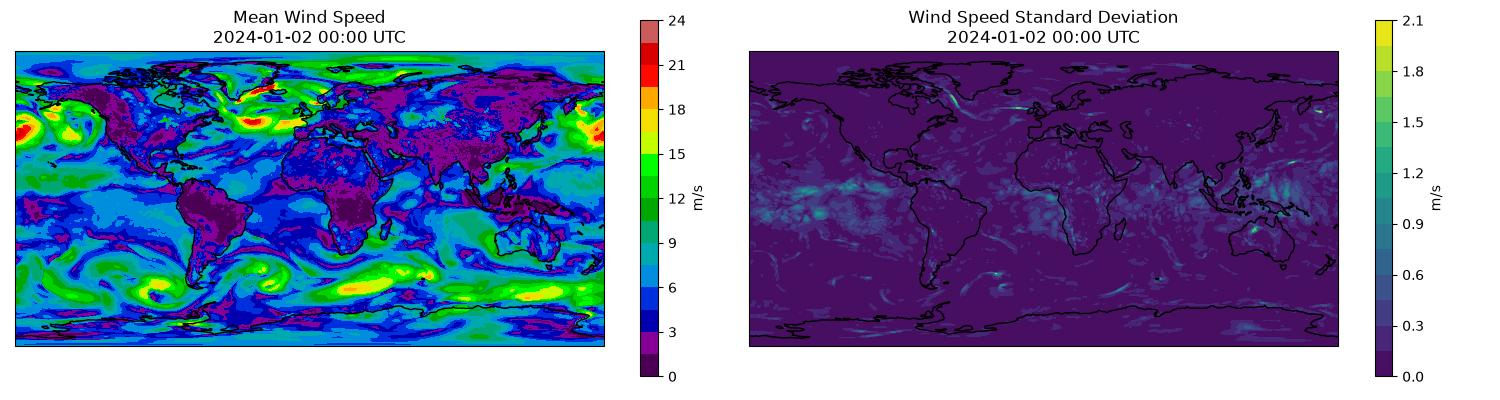

In [3]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

lead_time = 4
plot_date = start_date + timedelta(hours=int(6 * lead_time))

# Load data from both zarr stores
ds0 = xr.open_zarr("outputs/11_hens_0.zarr")
ds1 = xr.open_zarr("outputs/11_hens_1.zarr")

# Combine the datasets
ds = xr.concat([ds0, ds1], dim="ensemble")

# Calculate wind speed magnitude
wind_speed = np.sqrt(ds.u10m**2 + ds.v10m**2)

# Get mean and std of 4th timestep across ensemble
mean_wind = wind_speed.isel(time=0, lead_time=lead_time).mean(dim="ensemble")
std_wind = wind_speed.isel(time=0, lead_time=lead_time).std(dim="ensemble")

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(15, 4), subplot_kw={"projection": ccrs.PlateCarree()}
)

# Plot mean
p1 = ax1.contourf(
    mean_wind.coords["lon"],
    mean_wind.coords["lat"],
    mean_wind,
    levels=15,
    transform=ccrs.PlateCarree(),
    cmap="nipy_spectral",
)
ax1.coastlines()
ax1.set_title(f'Mean Wind Speed\n{plot_date.strftime("%Y-%m-%d %H:%M UTC")}')
fig.colorbar(p1, ax=ax1, label="m/s")

# Plot standard deviation
p2 = ax2.contourf(
    std_wind.coords["lon"],
    std_wind.coords["lat"],
    std_wind,
    levels=15,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
)
ax2.coastlines()
ax2.set_title(
    f'Wind Speed Standard Deviation\n{plot_date.strftime("%Y-%m-%d %H:%M UTC")}'
)
fig.colorbar(p2, ax=ax2, label="m/s")

plt.tight_layout()
# Save the figure
plt.savefig(f"outputs/11_hens_step_{plot_date.strftime('%Y_%m_%d')}.jpg")
